In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd
# import dask.dataframe as dd
from statsmodels.tsa.stattools import adfuller
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.seasonal import seasonal_decompose
plt.rcParams['figure.figsize']=(20,5)

In [2]:
df=pd.read_parquet(R"D:\\Data.parquet")

In [3]:
# Assuming your DataFrame is named 'df'
df['aggregate_sum'] = df[['Appliance1', 'Appliance2', 'Appliance3', 'Appliance4', 'Appliance5', 'Appliance6', 'Appliance7', 'Appliance8', 'Appliance9']].sum(axis=1)


In [4]:
df.head()

,Time,Unix,Aggregate,Appliance1,Appliance2,Appliance3,Appliance4,Appliance5,Appliance6,Appliance7,Appliance8,Appliance9,aggregate_sum
0,2013-10-09 13:06:17,1381323977,523,74,0,69,0,0,0,0,0,1,144
1,2013-10-09 13:06:31,1381323991,526,75,0,69,0,0,0,0,0,1,145
2,2013-10-09 13:06:46,1381324006,540,74,0,68,0,0,0,0,0,1,143
3,2013-10-09 13:07:01,1381324021,532,74,0,68,0,0,0,0,0,1,143
4,2013-10-09 13:07:15,1381324035,540,74,0,69,0,0,0,0,0,1,144


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6960008 entries, 0 to 6960007
Data columns (total 13 columns):
 #   Column         Dtype 
---  ------         ----- 
 0   Time           object
 1   Unix           int64 
 2   Aggregate      int64 
 3   Appliance1     int64 
 4   Appliance2     int64 
 5   Appliance3     int64 
 6   Appliance4     int64 
 7   Appliance5     int64 
 8   Appliance6     int64 
 9   Appliance7     int64 
 10  Appliance8     int64 
 11  Appliance9     int64 
 12  aggregate_sum  int64 
dtypes: int64(12), object(1)
memory usage: 690.3+ MB


In [4]:




# Convert 'Time' column to datetime format
df['Time'] = pd.to_datetime(df['Time'])

# Set 'Time' as the index (required for resampling)
df.set_index('Time', inplace=True)

# Resample with a 20-second interval and sum the values in each interval
# You can change '20S' to other time frequencies as needed
df_resampled = df.resample('1H').sum()

# Reset the index to make 'Time' a regular column again
df_resampled.reset_index(inplace=True)

# Overwrite the original CSV file with the resampled data


# Display the resampled DataFrame
print(df_resampled.head())


                 Time          Unix  Aggregate  Appliance1  Appliance2  \
0 2013-10-09 13:00:00  729339918344     512046        9000        9920   
1 2013-10-09 14:00:00  795645479832     375149        1639       10485   
2 2013-10-09 15:00:00  787359569031     341697       20787        9865   
3 2013-10-09 16:00:00  785980258859     165559         404        9729   
4 2013-10-09 17:00:00  639560303853     141451       17561        9724   

   Appliance3  Appliance4  Appliance5  Appliance6  Appliance7  Appliance8  \
0        1175           0           0           0           0           0   
1       24069           0           0           0           0           0   
2       21139           0           0           0           0           0   
3        5542           0           0           0           0           0   
4       16660           8           0           0           0       13714   

   Appliance9  
0         528  
1         576  
2         570  
3         568  
4         46

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6960008 entries, 2013-10-09 13:06:17 to 2015-07-10 11:56:32
Data columns (total 11 columns):
 #   Column      Dtype
---  ------      -----
 0   Unix        int64
 1   Aggregate   int64
 2   Appliance1  int64
 3   Appliance2  int64
 4   Appliance3  int64
 5   Appliance4  int64
 6   Appliance5  int64
 7   Appliance6  int64
 8   Appliance7  int64
 9   Appliance8  int64
 10  Appliance9  int64
dtypes: int64(11)
memory usage: 637.2 MB


In [84]:
print(df_resampled.head())

                 Time        Unix  Aggregate  Appliance1  Appliance2  \
0 2013-10-09 13:06:00  1381323977        523          74           0   
1 2013-10-09 13:06:20  1381323991        526          75           0   
2 2013-10-09 13:06:40  1381324006        540          74           0   
3 2013-10-09 13:07:00  4143972094       1611         222           0   
4 2013-10-09 13:07:20  2762648102       1074         148           0   

   Appliance3  Appliance4  Appliance5  Appliance6  Appliance7  Appliance8  \
0          69           0           0           0           0           0   
1          69           0           0           0           0           0   
2          68           0           0           0           0           0   
3         206           0           0           0           0           0   
4         138           0           0           0           0           0   

   Appliance9  
0           1  
1           1  
2           1  
3           3  
4           2  


In [15]:

# Assuming your DataFrame is named 'df' and 'Time' is the datetime column
# If 'Time' is not set as the index, you can use df.set_index('Time', inplace=True)

# Plot time series for the aggregated load with adjusted y-axis limits
'''plt.figure(figsize=(15, 5))
plt.plot(df.index, df['Aggregate'], label='Aggregated Load', color='green', linewidth=1)

# Adjust the y-axis limits
plt.ylim(0, 2000)  # Adjust the upper limit as needed

plt.xlabel('Time')
plt.ylabel('Aggregated Load')
plt.title('Aggregated Load Over Time')
plt.legend()
plt.show()'''


"plt.figure(figsize=(15, 5))\nplt.plot(df.index, df['Aggregate'], label='Aggregated Load', color='green', linewidth=1)\n\n# Adjust the y-axis limits\nplt.ylim(0, 2000)  # Adjust the upper limit as needed\n\nplt.xlabel('Time')\nplt.ylabel('Aggregated Load')\nplt.title('Aggregated Load Over Time')\nplt.legend()\nplt.show()"

ADF Statistic for window 0-5000: -6.800449441772209
p-value: 2.244104179586643e-09
The time series is likely stationary (reject the null hypothesis)
ADF Statistic for window 5000-10000: -8.726028516359582
p-value: 3.2868842220451146e-14
The time series is likely stationary (reject the null hypothesis)
ADF Statistic for window 10000-15000: -6.2045393633326205
p-value: 5.699902246207854e-08
The time series is likely stationary (reject the null hypothesis)
ADF Statistic for window 15000-20000: -3.935192040918824
p-value: 0.0017905889080982978
The time series is likely stationary (reject the null hypothesis)
ADF Statistic for window 20000-25000: -5.174317495333346
p-value: 9.917995907645441e-06
The time series is likely stationary (reject the null hypothesis)
ADF Statistic for window 25000-30000: -5.269259939117428
p-value: 6.338285121105211e-06
The time series is likely stationary (reject the null hypothesis)
ADF Statistic for window 30000-35000: -5.547867679976466
p-value: 1.645157841548

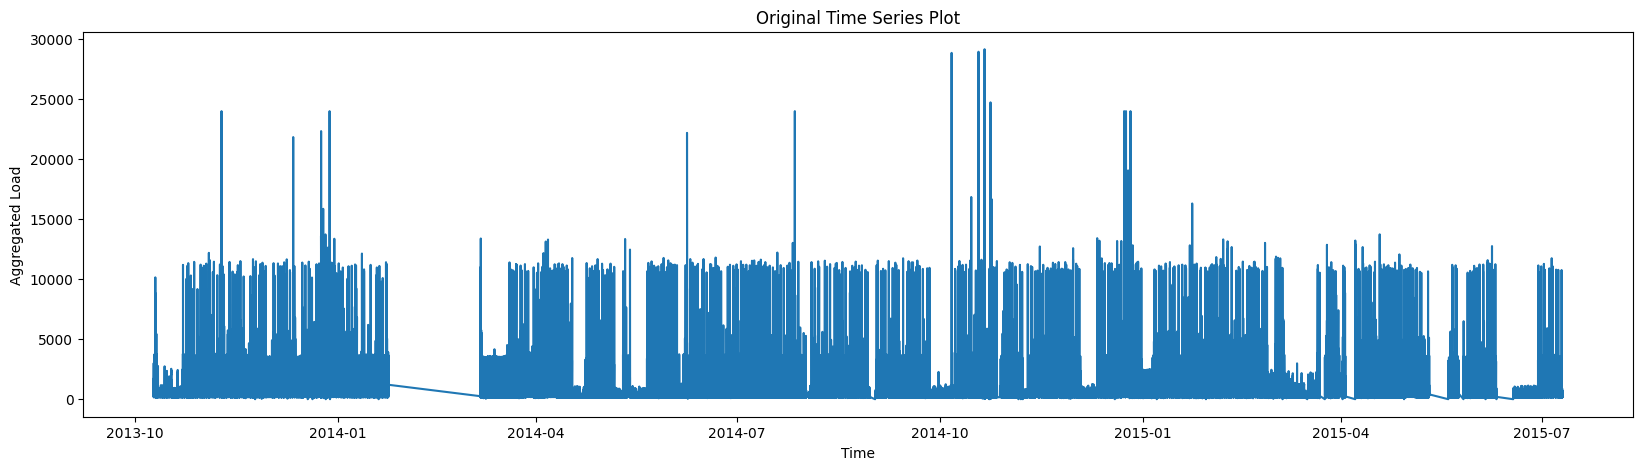

In [16]:


# Assuming your DataFrame is named 'df' and 'Timestamp' is the datetime column
# Replace 'Aggregate' with the actual column name you're interested in
time_series = df['Aggregate']

# Specify the rolling window size
window_size = 5000

# Iterate through the time series with a rolling window and perform ADF test
for i in range(0, len(time_series), window_size):
    windowed_series = time_series[i:i+window_size]
    result = adfuller(windowed_series, autolag='AIC')
    
    # Extract ADF test statistics and p-value
    adf_stat = result[0]
    p_value = result[1]

    # Print the results
    print(f'ADF Statistic for window {i}-{i+window_size}: {adf_stat}')
    print(f'p-value: {p_value}')

    # Check for significance
    if p_value <= 0.05:
        print('The time series is likely stationary (reject the null hypothesis)')
    else:
        print('The time series is likely non-stationary (fail to reject the null hypothesis)')

# Plot the original time series
plt.plot(df.index, time_series)
plt.xlabel('Time')
plt.ylabel('Aggregated Load')
plt.title('Original Time Series Plot')
plt.show()


In [20]:
# Assuming you have a DataFrame named 'df'

# Perform clustering with explicit n_init
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(df[['Aggregate', 'Appliance1', 'Appliance2', 'Appliance3', 'Appliance4', 'Appliance5', 'Appliance6', 'Appliance7', 'Appliance8', 'Appliance9']])

# Initialize cluster_data DataFrame outside the loop
cluster_data = pd.DataFrame()

# Iterate through clusters and fit linear regression models
for cluster in df['cluster'].unique():
    print(f"\nCluster {cluster}:")

    # Extract data for the current cluster
    current_cluster_data = df[df['cluster'] == cluster]

    # Display some information about the cluster data
    print(current_cluster_data.head())

    # Check if 'target' column exists in current_cluster_data
    if 'Aggregate' in current_cluster_data.columns:
        X = current_cluster_data[['Appliance1', 'Appliance2', 'Appliance3', 'Appliance4', 'Appliance5', 'Appliance6', 'Appliance7', 'Appliance8', 'Appliance9']]
        y = current_cluster_data['Aggregate']

        # Initialize and fit the linear regression model
        model = LinearRegression()
        model.fit(X, y)

        # Predict values for the same features
        predicted_values = model.predict(X)

        # Add the predicted values to the current_cluster_data DataFrame
        for i, appliance in enumerate(['Appliance1', 'Appliance2', 'Appliance3', 'Appliance4', 'Appliance5', 'Appliance6', 'Appliance7', 'Appliance8', 'Appliance9']):
            current_cluster_data[f'Predicted_{appliance}'] = predicted_values

        # Append current_cluster_data to cluster_data
        cluster_data = pd.concat([cluster_data, current_cluster_data], ignore_index=True)

        # Display the updated cluster_data with predicted values
        print(current_cluster_data[['Predicted_Appliance1', 'Predicted_Appliance2', 'Predicted_Appliance3', 'Predicted_Appliance4', 'Predicted_Appliance5', 'Predicted_Appliance6', 'Predicted_Appliance7', 'Predicted_Appliance8', 'Predicted_Appliance9']])
    else:
        print("'target' column not found in the current_cluster_data.")

# Print the columns after the loop
print(cluster_data.columns)



Cluster 0:
                           Unix  Aggregate  Appliance1  Appliance2  \
Time                                                                 
2013-10-09 13:06:17  1381323977        523          74           0   
2013-10-09 13:06:31  1381323991        526          75           0   
2013-10-09 13:06:46  1381324006        540          74           0   
2013-10-09 13:07:01  1381324021        532          74           0   
2013-10-09 13:07:15  1381324035        540          74           0   

                     Appliance3  Appliance4  Appliance5  Appliance6  \
Time                                                                  
2013-10-09 13:06:17          69           0           0           0   
2013-10-09 13:06:31          69           0           0           0   
2013-10-09 13:06:46          68           0           0           0   
2013-10-09 13:07:01          68           0           0           0   
2013-10-09 13:07:15          69           0           0           0   


C:\Users\anand\AppData\Local\Temp\ipykernel_18060\1888460530.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  current_cluster_data[f'Predicted_{appliance}'] = predicted_values
C:\Users\anand\AppData\Local\Temp\ipykernel_18060\1888460530.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  current_cluster_data[f'Predicted_{appliance}'] = predicted_values
C:\Users\anand\AppData\Local\Temp\ipykernel_18060\1888460530.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Dat

                     Predicted_Appliance1  Predicted_Appliance2  \
Time                                                              
2013-10-09 13:06:17            310.751914            310.751914   
2013-10-09 13:06:31            311.180139            311.180139   
2013-10-09 13:06:46            310.142397            310.142397   
2013-10-09 13:07:01            310.142397            310.142397   
2013-10-09 13:07:15            310.751914            310.751914   
...                                   ...                   ...   
2015-07-10 11:56:05            250.236285            250.236285   
2015-07-10 11:56:12            250.236285            250.236285   
2015-07-10 11:56:18            250.236285            250.236285   
2015-07-10 11:56:25            250.236285            250.236285   
2015-07-10 11:56:32            250.236285            250.236285   

                     Predicted_Appliance3  Predicted_Appliance4  \
Time                                                         

C:\Users\anand\AppData\Local\Temp\ipykernel_18060\1888460530.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  current_cluster_data[f'Predicted_{appliance}'] = predicted_values
C:\Users\anand\AppData\Local\Temp\ipykernel_18060\1888460530.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  current_cluster_data[f'Predicted_{appliance}'] = predicted_values
C:\Users\anand\AppData\Local\Temp\ipykernel_18060\1888460530.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Dat

                     Predicted_Appliance1  Predicted_Appliance2  \
Time                                                              
2013-10-09 13:18:45           2571.627697           2571.627697   
2013-10-09 13:18:46           2572.535356           2572.535356   
2013-10-09 13:18:59           2572.535356           2572.535356   
2013-10-09 13:19:00           2572.535356           2572.535356   
2013-10-09 13:19:14           2572.535356           2572.535356   
...                                   ...                   ...   
2015-07-09 23:00:49           2684.149737           2684.149737   
2015-07-09 23:00:56           2679.657425           2679.657425   
2015-07-09 23:01:03           2733.565170           2733.565170   
2015-07-09 23:01:10           2688.816556           2688.816556   
2015-07-09 23:01:16           2684.149737           2684.149737   

                     Predicted_Appliance3  Predicted_Appliance4  \
Time                                                         

C:\Users\anand\AppData\Local\Temp\ipykernel_18060\1888460530.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  current_cluster_data[f'Predicted_{appliance}'] = predicted_values
C:\Users\anand\AppData\Local\Temp\ipykernel_18060\1888460530.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  current_cluster_data[f'Predicted_{appliance}'] = predicted_values
C:\Users\anand\AppData\Local\Temp\ipykernel_18060\1888460530.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Dat

                     Predicted_Appliance1  Predicted_Appliance2  \
Time                                                              
2013-10-10 07:13:17          10137.754107          10137.754107   
2013-10-10 07:13:18          10137.754107          10137.754107   
2013-10-10 07:45:01          10257.930330          10257.930330   
2013-10-10 07:45:02          10257.930330          10257.930330   
2013-10-10 07:45:16          10257.930330          10257.930330   
...                                   ...                   ...   
2015-07-09 23:49:00          10279.986017          10279.986017   
2015-07-09 23:49:06          10280.643027          10280.643027   
2015-07-09 23:49:13          10279.193147          10279.193147   
2015-07-09 23:49:20          10279.193147          10279.193147   
2015-07-09 23:49:27          10279.193147          10279.193147   

                     Predicted_Appliance3  Predicted_Appliance4  \
Time                                                         

In [72]:


# Assuming you have a DataFrame named 'df' with columns 'Aggregate', 'Appliance1', ..., 'Appliance9'
# Replace 'YourDataFrame' and 'YourColumns' with the actual names in your dataset
columns_to_difference = ['Aggregate', 'Appliance1', 'Appliance2', 'Appliance3', 'Appliance4', 'Appliance5', 'Appliance6', 'Appliance7', 'Appliance8', 'Appliance9']

# Apply differencing to each column
df_differenced = df[columns_to_difference].diff().dropna()

# Display the differenced DataFrame
print(df_differenced.head())


                     Aggregate  Appliance1  Appliance2  Appliance3  \
Time                                                                 
2013-10-09 13:06:31        3.0         1.0         0.0         0.0   
2013-10-09 13:06:46       14.0        -1.0         0.0        -1.0   
2013-10-09 13:07:01       -8.0         0.0         0.0         0.0   
2013-10-09 13:07:15        8.0         0.0         0.0         1.0   
2013-10-09 13:07:18       -1.0         0.0         0.0         0.0   

                     Appliance4  Appliance5  Appliance6  Appliance7  \
Time                                                                  
2013-10-09 13:06:31         0.0         0.0         0.0         0.0   
2013-10-09 13:06:46         0.0         0.0         0.0         0.0   
2013-10-09 13:07:01         0.0         0.0         0.0         0.0   
2013-10-09 13:07:15         0.0         0.0         0.0         0.0   
2013-10-09 13:07:18         0.0         0.0         0.0         0.0   

           

In [22]:


# Assuming you have a DataFrame named 'df_differenced'
# Replace 'YourDataFrame' with the actual name in your dataset

# Specify the chunk size
chunk_size = 10000

# Get the number of chunks needed
num_chunks = len(df_differenced) // chunk_size + 1

# Perform ADF test for each chunk
for i in range(num_chunks):
    start_idx = i * chunk_size
    end_idx = min((i + 1) * chunk_size, len(df_differenced))
    
    result = adfuller(df_differenced['Aggregate'].iloc[start_idx:end_idx], autolag='AIC')

    # Extract and print the p-value
    p_value = result[1]
    print(f'ADF Test p-value for chunk {i+1}: {p_value}')

    # Check the p-value against the significance level (e.g., 0.05)
    if p_value <= 0.05:
        print(f'The time series data in chunk {i+1} is likely stationary.')
    else:
        print(f'The time series data in chunk {i+1} is likely non-stationary.')


ADF Test p-value for chunk 1: 0.0
The time series data in chunk 1 is likely stationary.
ADF Test p-value for chunk 2: 0.0
The time series data in chunk 2 is likely stationary.
ADF Test p-value for chunk 3: 0.0
The time series data in chunk 3 is likely stationary.
ADF Test p-value for chunk 4: 0.0
The time series data in chunk 4 is likely stationary.
ADF Test p-value for chunk 5: 0.0
The time series data in chunk 5 is likely stationary.
ADF Test p-value for chunk 6: 0.0
The time series data in chunk 6 is likely stationary.
ADF Test p-value for chunk 7: 6.35599799820634e-29
The time series data in chunk 7 is likely stationary.
ADF Test p-value for chunk 8: 0.0
The time series data in chunk 8 is likely stationary.
ADF Test p-value for chunk 9: 5.073057226652345e-30
The time series data in chunk 9 is likely stationary.
ADF Test p-value for chunk 10: 0.0
The time series data in chunk 10 is likely stationary.
ADF Test p-value for chunk 11: 0.0
The time series data in chunk 11 is likely stati

In [23]:


# Assuming your DataFrame is named 'df' and 'Time' is the datetime column
# If 'Time' is not set as the index, you can use df.set_index('Time', inplace=True)

# Plot time series for the aggregated load with adjusted y-axis limits
'''plt.figure(figsize=(15, 5))
plt.plot(df.index, df['Aggregate'], label='Aggregated Load', color='green', linewidth=1)

# Adjust the y-axis limits
plt.ylim(0, 2000)  # Adjust the upper limit as needed

plt.xlabel('Time')
plt.ylabel('Aggregated Load')
plt.title('Aggregated Load Over Time')
plt.legend()
plt.show()'''


"plt.figure(figsize=(15, 5))\nplt.plot(df.index, df['Aggregate'], label='Aggregated Load', color='green', linewidth=1)\n\n# Adjust the y-axis limits\nplt.ylim(0, 2000)  # Adjust the upper limit as needed\n\nplt.xlabel('Time')\nplt.ylabel('Aggregated Load')\nplt.title('Aggregated Load Over Time')\nplt.legend()\nplt.show()"

In [24]:


# Assuming your DataFrame is named 'df' and 'Time' is the datetime column
# If 'Time' is not set as the index, you can use df.set_index('Time', inplace=True)

# Plot time series for the aggregated load with adjusted y-axis limits
'''plt.figure(figsize=(15, 5))
plt.plot(df.index, df['Appliance1'], label='Appliance1', color='green', linewidth=1)
#1.Fridge
# Adjust the y-axis limits
plt.ylim(0, 2000)  # Adjust the upper limit as needed

plt.xlabel('Time')
plt.ylabel('Appliance1')
plt.title('Appliance1 Over Time')
plt.legend()
plt.show()'''


"plt.figure(figsize=(15, 5))\nplt.plot(df.index, df['Appliance1'], label='Appliance1', color='green', linewidth=1)\n#1.Fridge\n# Adjust the y-axis limits\nplt.ylim(0, 2000)  # Adjust the upper limit as needed\n\nplt.xlabel('Time')\nplt.ylabel('Appliance1')\nplt.title('Appliance1 Over Time')\nplt.legend()\nplt.show()"

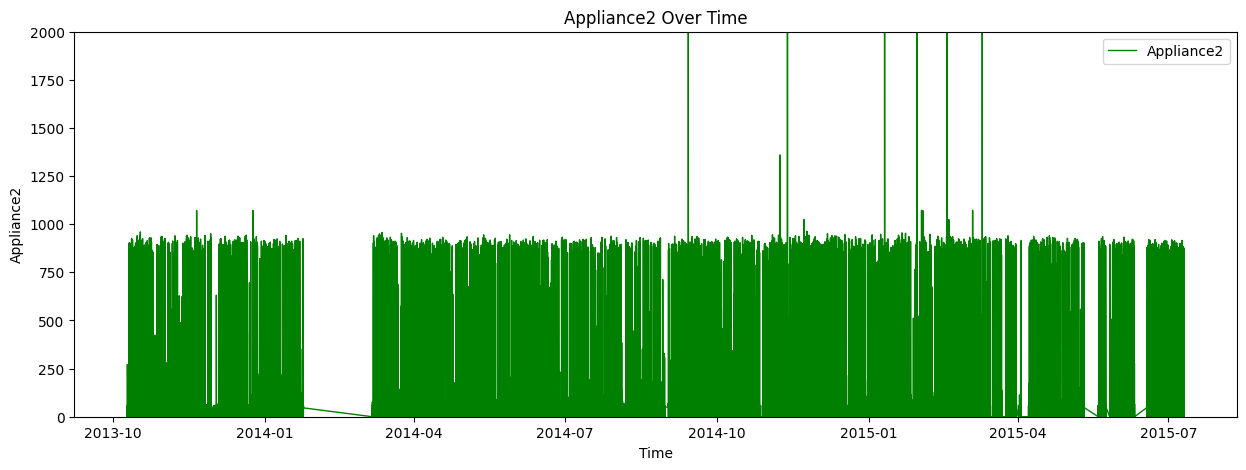

In [27]:


# Assuming your DataFrame is named 'df' and 'Time' is the datetime column
# If 'Time' is not set as the index, you can use df.set_index('Time', inplace=True)

# Plot time series for the aggregated load with adjusted y-axis limits
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['Appliance2'], label='Appliance2', color='green', linewidth=1)
#2.Chest Freezer,
# Adjust the y-axis limits
plt.ylim(0, 2000)  # Adjust the upper limit as needed

plt.xlabel('Time')
plt.ylabel('Appliance2')
plt.title('Appliance2 Over Time')
plt.legend()
plt.show()


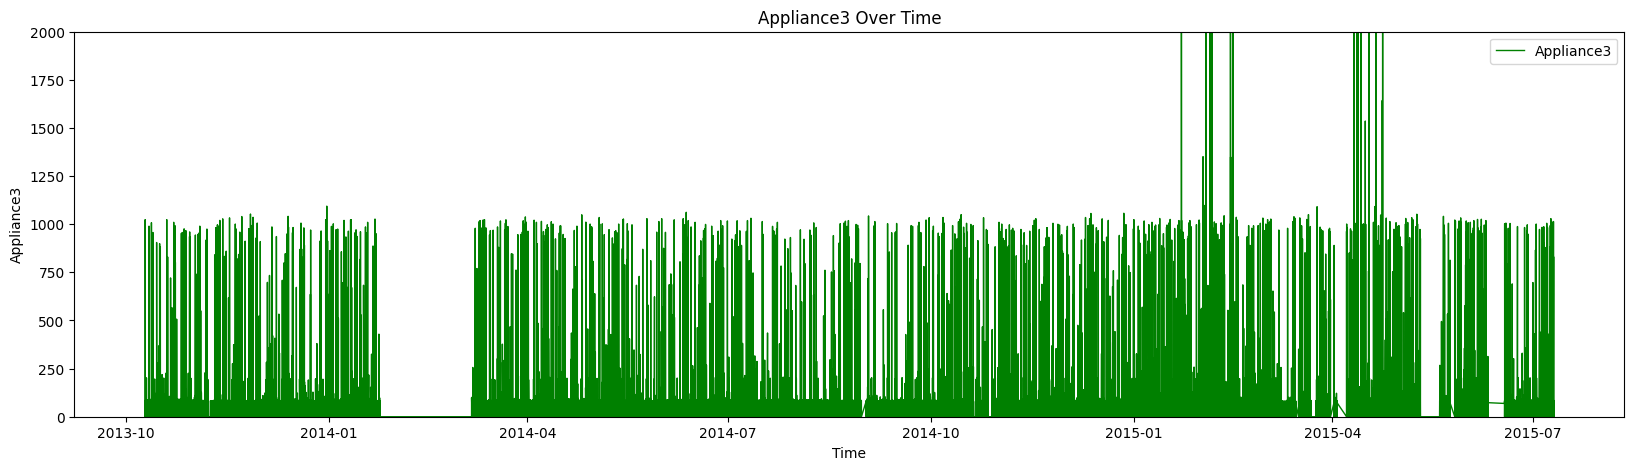

In [28]:



# Assuming your DataFrame is named 'df' and 'Time' is the datetime column
# If 'Time' is not set as the index, you can use df.set_index('Time', inplace=True)

# Plot time series for the aggregated load with adjusted y-axis limits
plt.rcParams['figure.figsize']=(20,5)
plt.plot(df.index, df['Appliance3'], label='Appliance3', color='green', linewidth=1)
#3.Upright Freezer
# Adjust the y-axis limits
plt.ylim(0, 2000)  # Adjust the upper limit as needed

plt.xlabel('Time')
plt.ylabel('Appliance3')
plt.title('Appliance3 Over Time')
plt.legend()
plt.show()


c:\Users\anand\AppData\Local\Programs\Python\Python310\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


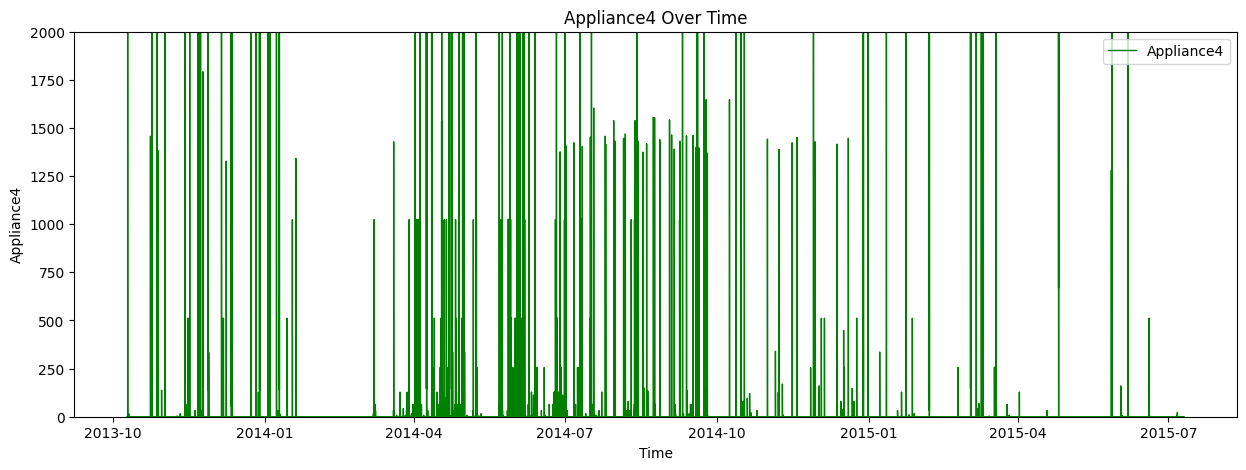

In [29]:



# Assuming your DataFrame is named 'df' and 'Time' is the datetime column
# If 'Time' is not set as the index, you can use df.set_index('Time', inplace=True)

# Plot time series for the aggregated load with adjusted y-axis limits
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['Appliance4'], label='Appliance4', color='green', linewidth=1)
#4.Tumble Dryer,
# Adjust the y-axis limits
plt.ylim(0, 2000)  # Adjust the upper limit as needed

plt.xlabel('Time')
plt.ylabel('Appliance4')
plt.title('Appliance4 Over Time')
plt.legend()
plt.show()


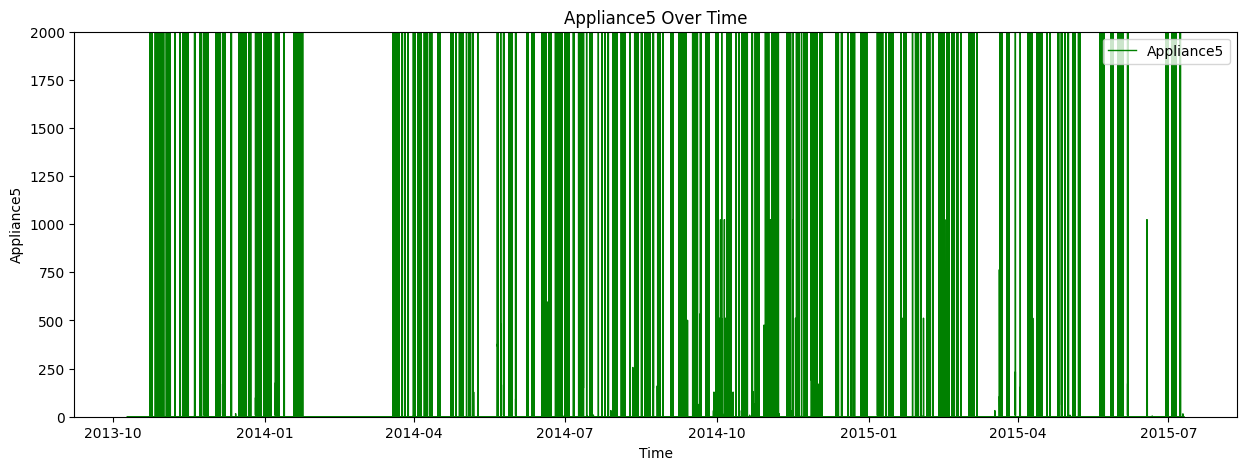

In [30]:


# Assuming your DataFrame is named 'df' and 'Time' is the datetime column
# If 'Time' is not set as the index, you can use df.set_index('Time', inplace=True)

# Plot time series for the aggregated load with adjusted y-axis limits
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['Appliance5'], label='Appliance5', color='green', linewidth=1)
#5.Washing Machine
# Adjust the y-axis limits
plt.ylim(0, 2000)  # Adjust the upper limit as needed

plt.xlabel('Time')
plt.ylabel('Appliance5')
plt.title('Appliance5 Over Time')
plt.legend()
plt.show()


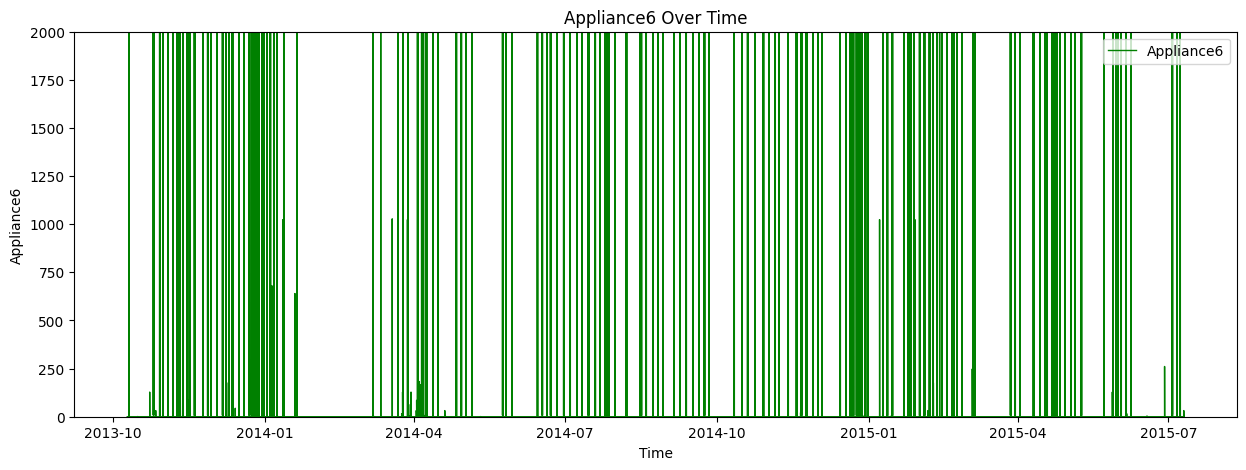

In [31]:


# Assuming your DataFrame is named 'df' and 'Time' is the datetime column
# If 'Time' is not set as the index, you can use df.set_index('Time', inplace=True)

# Plot time series for the aggregated load with adjusted y-axis limits
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['Appliance6'], label='Appliance6', color='green', linewidth=1)
#6.Dishwasher
# Adjust the y-axis limits
plt.ylim(0, 2000)  # Adjust the upper limit as needed

plt.xlabel('Time')
plt.ylabel('Appliance6')
plt.title('Appliance6 Over Time')
plt.legend()
plt.show()


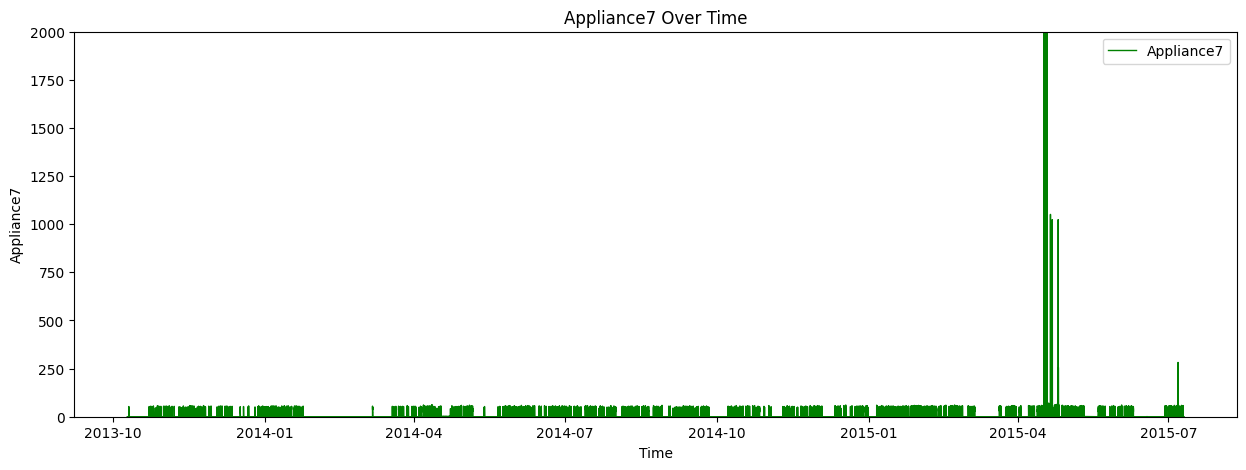

In [32]:



# Assuming your DataFrame is named 'df' and 'Time' is the datetime column
# If 'Time' is not set as the index, you can use df.set_index('Time', inplace=True)

# Plot time series for the aggregated load with adjusted y-axis limits
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['Appliance7'], label='Appliance7', color='green', linewidth=1)
#7.Computer Site
# Adjust the y-axis limits
plt.ylim(0, 2000)  # Adjust the upper limit as needed

plt.xlabel('Time')
plt.ylabel('Appliance7')
plt.title('Appliance7 Over Time')
plt.legend()
plt.show()


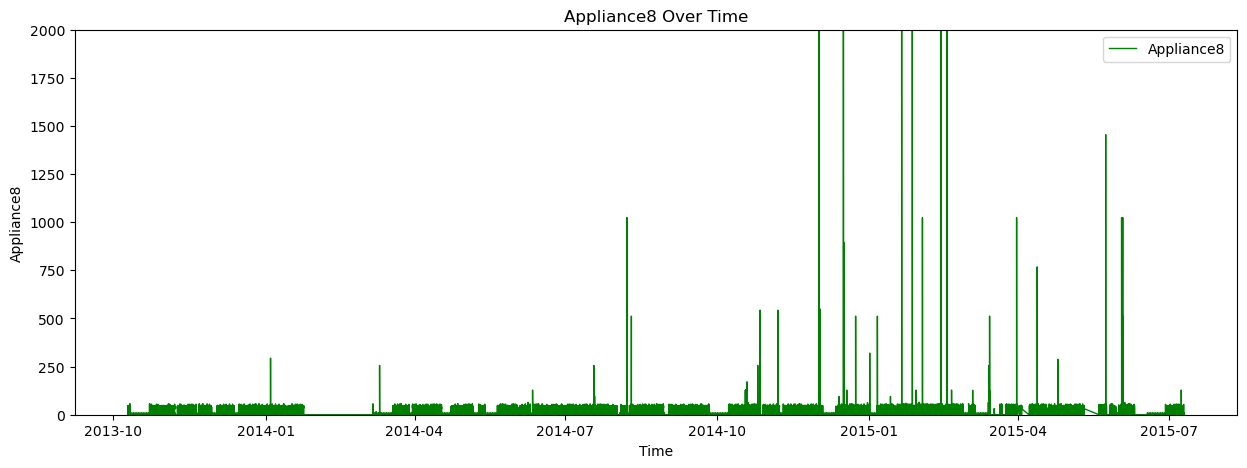

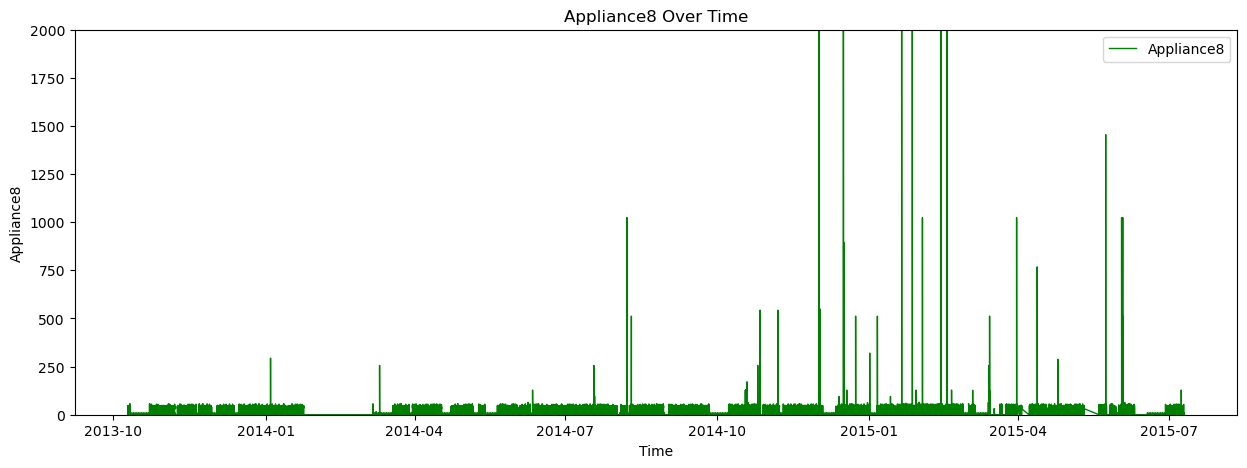

In [ ]:



# Assuming your DataFrame is named 'df' and 'Time' is the datetime column
# If 'Time' is not set as the index, you can use df.set_index('Time', inplace=True)

# Plot time series for the aggregated load with adjusted y-axis limits
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['Appliance8'], label='Appliance8', color='green', linewidth=1)
#8.Television Site
# Adjust the y-axis limits
plt.ylim(0, 2000)  # Adjust the upper limit as needed

plt.xlabel('Time')
plt.ylabel('Appliance8')
plt.title('Appliance8 Over Time')
plt.legend()
plt.show()


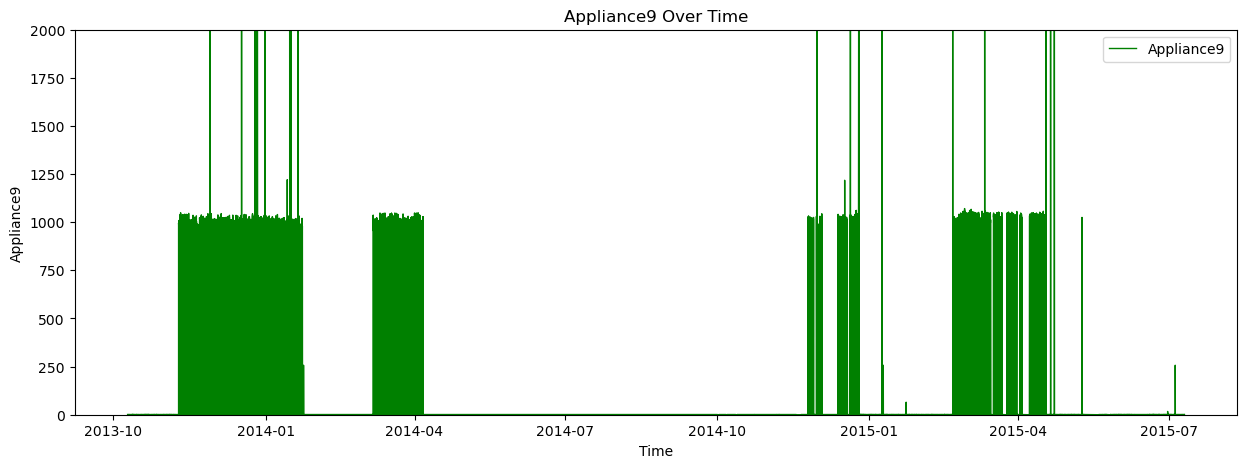

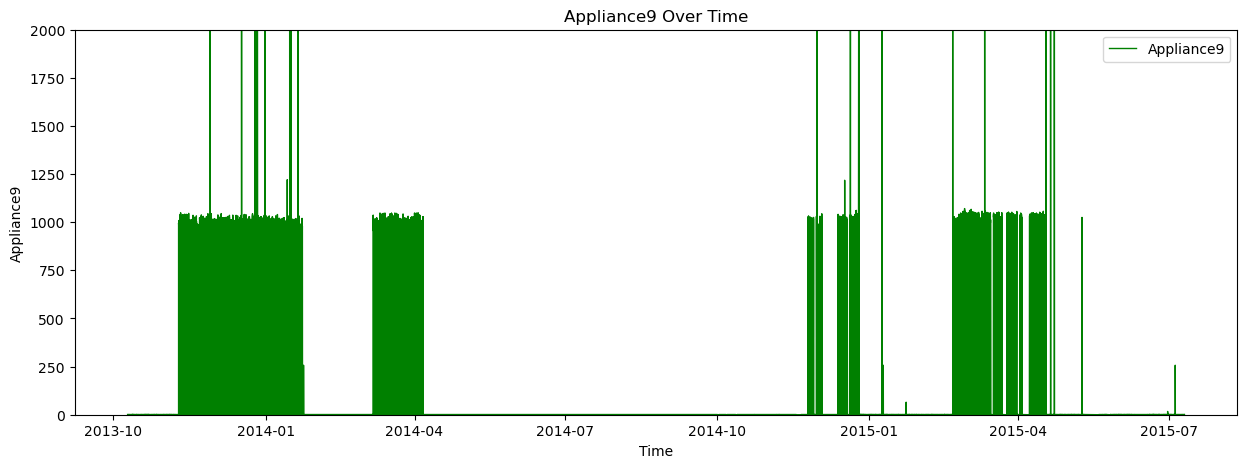

In [ ]:



# Assuming your DataFrame is named 'df' and 'Time' is the datetime column
# If 'Time' is not set as the index, you can use df.set_index('Time', inplace=True)

# Plot time series for the aggregated load with adjusted y-axis limits
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['Appliance9'], label='Appliance9', color='green', linewidth=1)
#9.Electric Heater
# Adjust the y-axis limits
plt.ylim(0, 2000)  # Adjust the upper limit as needed

plt.xlabel('Time')
plt.ylabel('Appliance9')
plt.title('Appliance9 Over Time')
plt.legend()
plt.show()


In [73]:


# Assuming you have a DataFrame named 'df' with a datetime index
# Replace 'YourColumn' with the actual column name in your dataset
your_column_name = 'Aggregate'

# Specify the window size for the moving average
window_size = 3  # You can adjust this based on your requirements

# Calculate the Simple Moving Average
df['SMA'] = df[your_column_name].rolling(window=window_size).mean()

# Drop rows with NaN values introduced by the rolling mean calculation
df.dropna(inplace=True)

# Print or visualize the original and smoothed data
print(df[[your_column_name, 'SMA']])


                     Aggregate         SMA
Time                                      
2013-10-09 13:06:46        540  529.666667
2013-10-09 13:07:01        532  532.666667
2013-10-09 13:07:15        540  537.333333
2013-10-09 13:07:18        539  537.000000
2013-10-09 13:07:30        537  538.666667
...                        ...         ...
2015-07-10 11:56:05        187  183.000000
2015-07-10 11:56:12        185  184.000000
2015-07-10 11:56:18        181  184.333333
2015-07-10 11:56:25        186  184.000000
2015-07-10 11:56:32        182  183.000000

[6960006 rows x 2 columns]


In [34]:


# Assuming you have a DataFrame named 'df' with a column named 'Aggregate' and a 'Time' index
# Replace 'YourDataFrame' and 'YourColumnName' with the actual names in your dataset
# You may also need to adjust the span parameter based on your data characteristics

# Calculate EMA with a specified span (adjust span as needed)
df['EMA'] = df['Aggregate'].ewm(span=10, adjust=False).mean()

# Display the DataFrame with the EMA column
print(df.head())


                           Unix  Aggregate  Appliance1  Appliance2  \
Time                                                                 
2013-10-09 13:06:46  1381324006        540          74           0   
2013-10-09 13:07:01  1381324021        532          74           0   
2013-10-09 13:07:15  1381324035        540          74           0   
2013-10-09 13:07:18  1381324038        539          74           0   
2013-10-09 13:07:30  1381324050        537          74           0   

                     Appliance3  Appliance4  Appliance5  Appliance6  \
Time                                                                  
2013-10-09 13:06:46          68           0           0           0   
2013-10-09 13:07:01          68           0           0           0   
2013-10-09 13:07:15          69           0           0           0   
2013-10-09 13:07:18          69           0           0           0   
2013-10-09 13:07:30          69           0           0           0   

           

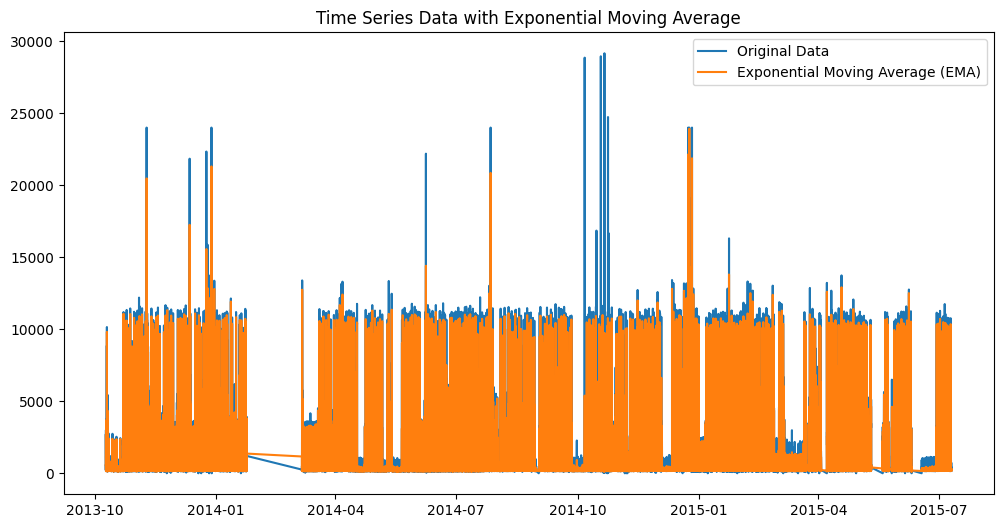

MemoryError: Unable to allocate 10.2 GiB for an array with shape (6960200, 196) and data type float64

In [35]:


# Assuming you have a DataFrame named 'df' with a column named 'Aggregate' and a 'Time' index
# Replace 'YourDataFrame' and 'YourColumnName' with the actual names in your dataset

# Plot the time series data
plt.figure(figsize=(12, 6))
plt.plot(df['Aggregate'], label='Original Data')
plt.plot(df['EMA'], label='Exponential Moving Average (EMA)')
plt.title('Time Series Data with Exponential Moving Average')
plt.legend()
plt.show()

# ADF Test for stationarity
result_adf = adfuller(df['Aggregate'], autolag='AIC')

# Extract and print the p-value
p_value_adf = result_adf[1]
print(f'ADF Test p-value: {p_value_adf}')

# Check the p-value against the significance level (e.g., 0.05)
if p_value_adf <= 0.05:
    print('The time series data is likely stationary.')
else:
    print('The time series data is likely non-stationary.')


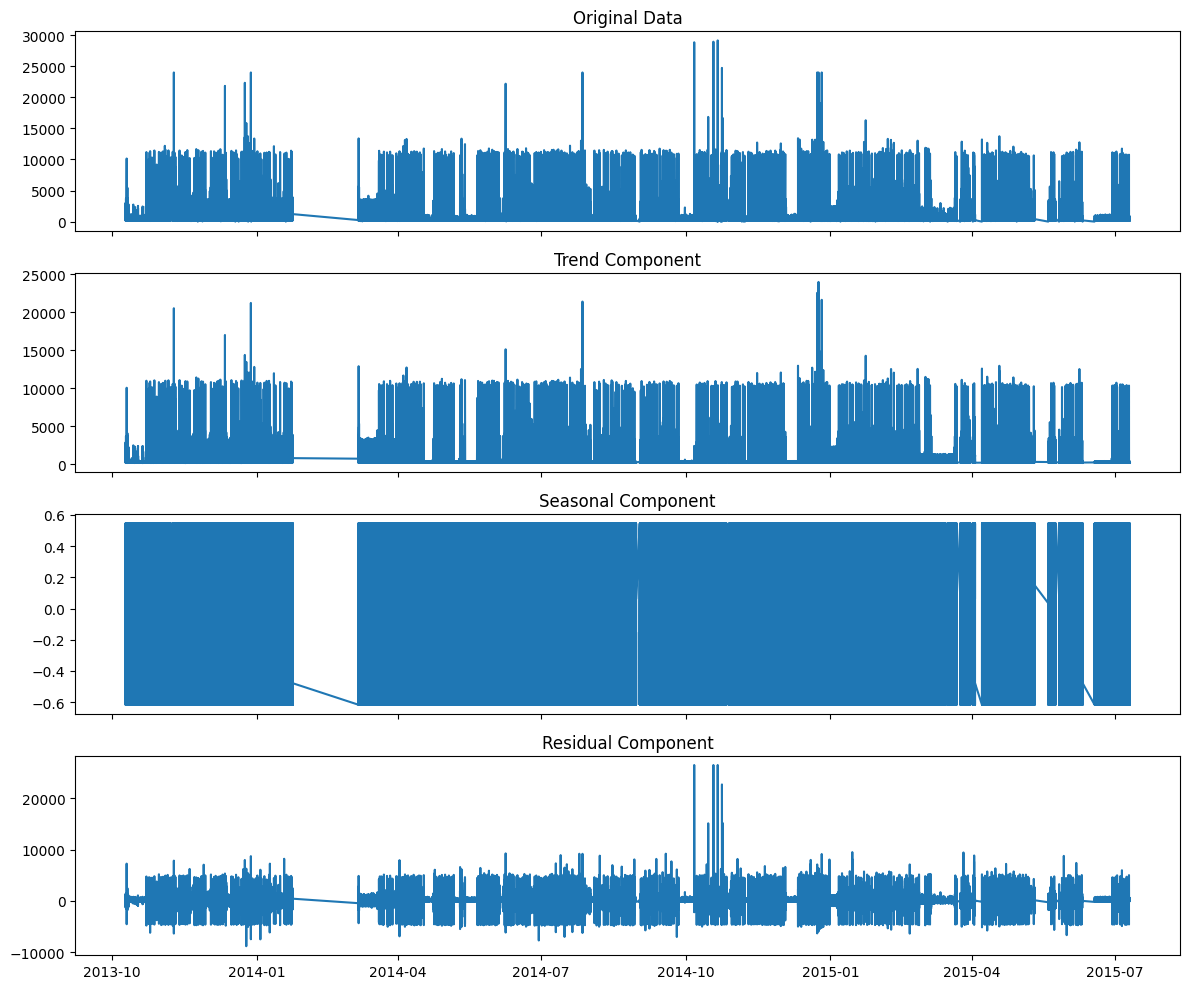

In [36]:


# Assuming you have a DataFrame named 'df' with a column named 'Aggregate' and a 'Time' index
# Replace 'YourDataFrame' and 'YourColumnName' with the actual names in your dataset

# Perform seasonal decomposition
result = seasonal_decompose(df['Aggregate'], period=13)  # You may need to adjust the period parameter

# Plot the decomposition components
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

ax1.plot(df['Aggregate'], label='Original Data')
ax1.set_title('Original Data')

ax2.plot(result.trend, label='Trend')
ax2.set_title('Trend Component')

ax3.plot(result.seasonal, label='Seasonal')
ax3.set_title('Seasonal Component')

ax4.plot(result.resid, label='Residual')
ax4.set_title('Residual Component')

plt.tight_layout()
plt.show()


ADF Test p-value: 0.0
Critical Values: {'1%': -3.430444033235823, '5%': -2.8615815610164606, '10%': -2.566792121509686}
The time series data is likely stationary based on the p-value.
The ADF statistic is lower than the critical value at 1%. The data is likely stationary.
The ADF statistic is lower than the critical value at 5%. The data is likely stationary.
The ADF statistic is lower than the critical value at 10%. The data is likely stationary.


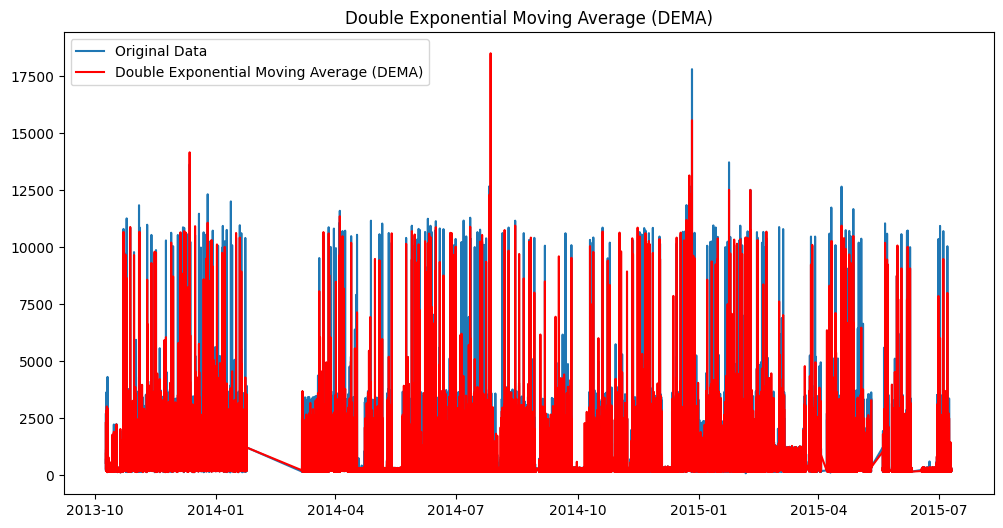

In [37]:



# Define the smoothing constants (alpha and beta)
alpha = 0.2  # You can adjust these values based on your data
beta = 0.2

# Calculate the first-level smoothed series (EMA)
df['EMA'] = df['Aggregate'].ewm(alpha=alpha, adjust=False).mean()

# Calculate the second-level smoothed series (DEMA)
df['DEMA'] = df['EMA'].ewm(alpha=beta, adjust=False).mean()

# Sample every N points for analysis
N = 100
subset_df = df.iloc[::N]

# Perform ADF test on the subset
result = adfuller(subset_df['DEMA'], autolag='AIC')

# Extract and print the p-value and critical values
p_value = result[1]
critical_values = result[4]

print(f'ADF Test p-value: {p_value}')
print(f'Critical Values: {critical_values}')

# Check the p-value against the significance level (e.g., 0.05)
if p_value <= 0.05:
    print('The time series data is likely stationary based on the p-value.')
else:
    print('The time series data is likely non-stationary based on the p-value.')

# Check the critical values
for key, value in critical_values.items():
    if result[0] < value:
        print(f'The ADF statistic is lower than the critical value at {key}. The data is likely stationary.')
    else:
        print(f'The ADF statistic is higher than the critical value at {key}. The data is likely non-stationary.')

# Plot the original data and the DEMA
plt.figure(figsize=(12, 6))
plt.plot(subset_df['Aggregate'], label='Original Data')
plt.plot(subset_df['DEMA'], label='Double Exponential Moving Average (DEMA)', color='red')
plt.title('Double Exponential Moving Average (DEMA)')
plt.legend()
plt.show()


In [38]:


# Assuming you have a DataFrame named 'df' with a column named 'DEMA'
# Replace 'YourDataFrame' and 'YourColumnName' with the actual names in your dataset
x = 5
# Perform ADF test

result = adfuller(df['DEMA'], autolag='AIC')


# Extract and print the p-value and critical values
p_value = result[1]
critical_values = result[4]

print(f'ADF Test p-value: {p_value}')
print(f'Critical Values: {critical_values}')

# Check the p-value against the significance level (e.g., 0.05)
if p_value <= 0.05:
    print('The time series data is likely stationary based on the p-value.')
else:
    print('The time series data is likely non-stationary based on the p-value.')

# Check the critical values
for key, value in critical_values.items():
    if result[0] < value:
        print(f'The ADF statistic is lower than the critical value at {key}. The data is likely stationary.')
    else:
        print(f'The ADF statistic is higher than the critical value at {key}. The data is likely non-stationary.')


MemoryError: Unable to allocate 10.2 GiB for an array with shape (6960200, 196) and data type float64

In [85]:
import pandas as pd

# Assuming you have a DataFrame named 'df'
# Replace 'YourDataFrame' and 'YourColumns' with the actual names in your dataset

# Define columns to consider
columns_to_consider = ['Aggregate', 'Appliance1', 'Appliance5', 'Appliance6', 'Appliance8']

# Calculate correlation coefficients
correlations = df[columns_to_consider].corr()

# Print correlation coefficients
print(correlations)


            Aggregate  Appliance1  Appliance5  Appliance6  Appliance8
Aggregate    1.000000    0.026594    0.207421    0.207879    0.042450
Appliance1   0.026594    1.000000   -0.003708    0.006520    0.015643
Appliance5   0.207421   -0.003708    1.000000   -0.002196   -0.020275
Appliance6   0.207879    0.006520   -0.002196    1.000000   -0.017327
Appliance8   0.042450    0.015643   -0.020275   -0.017327    1.000000


In [41]:





# Assuming you have a DataFrame named 'df' with the relevant columns
# Replace 'YourDataFrame' and 'YourColumns' with the actual names in your dataset

# Plot scatter plots for each individual appliance against the aggregated column
for appliance in ['Appliance1', 'Appliance4', 'Appliance5',
                   'Appliance6', 'Appliance8', 'Appliance9']:
    plt.scatter(df['Aggregate'], df[appliance], label=appliance)

# Add labels and legend


KeyboardInterrupt: 

In [ ]:
plt.xlabel('Aggregate')
plt.ylabel('Individual Appliances')
plt.legend()
plt.title('Scatter Plots of Aggregate vs Individual Appliances')
plt.show()


In [111]:
print(df.index)

DatetimeIndex(['2013-10-09 13:06:17', '2013-10-09 13:06:31',
               '2013-10-09 13:06:46', '2013-10-09 13:07:01',
               '2013-10-09 13:07:15', '2013-10-09 13:07:18',
               '2013-10-09 13:07:30', '2013-10-09 13:07:32',
               '2013-10-09 13:07:44', '2013-10-09 13:07:47',
               ...
               '2015-07-10 11:55:31', '2015-07-10 11:55:38',
               '2015-07-10 11:55:45', '2015-07-10 11:55:52',
               '2015-07-10 11:55:58', '2015-07-10 11:56:05',
               '2015-07-10 11:56:12', '2015-07-10 11:56:18',
               '2015-07-10 11:56:25', '2015-07-10 11:56:32'],
              dtype='datetime64[ns]', name='Time', length=6960008, freq=None)


In [19]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler


In [20]:

# Assuming your DataFrame is named 'df' with a 'Time' column
# Replace 'YourTargetColumns' with the actual names of your target columns
target_columns = ['Aggregate', 'Unix', 'Appliance1', 'Appliance4', 'Appliance5', 'Appliance6', 'Appliance8', 'Appliance9']
features = ['Aggregate']

subset_df = df.sample(frac=0.02, random_state=42)
subset_df.set_index('Time', inplace=True)


In [21]:

X = subset_df.drop(target_columns, axis=1)  # Features
y = subset_df[features]  # Target variables

min_samples = min(X.shape[0], y.shape[0])
X = X[:min_samples]
y = y[:min_samples]

xN = X.to_numpy()
yN = y.to_numpy()
y_new = yN.flatten()


In [22]:

X_train, X_test, y_train, y_test = train_test_split(xN, y_new, test_size=0.3, random_state=42, shuffle=True)


In [23]:

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [24]:

# Initialize the Logistic Regression model
model = LogisticRegression(max_iter=1000)

# Train the model on scaled data
model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred = model.predict(X_test_scaled)


In [25]:

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

# Print results
print(f'Accuracy: {accuracy}')
print(f'Confusion Matrix:\n{conf_matrix}')
print(f'Classification Report:\n{classification_rep}')


Accuracy: 0.026173371647509578
Confusion Matrix:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
Classification Report:
              precision    recall  f1-score   support

         118       0.00      0.00      0.00         1
         125       0.00      0.00      0.00         1
         126       0.00      0.00      0.00         1
         127       0.00      0.00      0.00         1
         128       0.00      0.00      0.00         1
         131       0.00      0.00      0.00         2
         133       0.00      0.00      0.00         3
         135       0.00      0.00      0.00         1
         136       0.00      0.00      0.00         1
         138       0.00      0.00      0.00         2
         139       0.00      0.00      0.00         2
         141       0.00      0.00      0.00         3
         142       0.00      0.00      0.00         4
         143       0.00      0.00      0.00        

c:\Users\anand\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\anand\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\anand\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifie

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

# Assuming your DataFrame is named 'df' with a 'Time' column
# Replace 'YourTargetColumns' with the actual names of your target columns
target_columns = ['Aggregate','aggregate_sum','Time','Unix','Appliance1', 'Appliance4', 'Appliance5', 'Appliance6', 'Appliance8', 'Appliance9']
features=['aggregate_sum']


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6960008 entries, 0 to 6960007
Data columns (total 13 columns):
 #   Column         Dtype 
---  ------         ----- 
 0   Time           object
 1   Unix           int64 
 2   Aggregate      int64 
 3   Appliance1     int64 
 4   Appliance2     int64 
 5   Appliance3     int64 
 6   Appliance4     int64 
 7   Appliance5     int64 
 8   Appliance6     int64 
 9   Appliance7     int64 
 10  Appliance8     int64 
 11  Appliance9     int64 
 12  aggregate_sum  int64 
dtypes: int64(12), object(1)
memory usage: 690.3+ MB


In [14]:

subset_df=df.sample(frac=0.02, random_state=42)

X= subset_df.drop(target_columns,axis=1)
y=subset_df[features]
#min_samples = min(X.shape[0],y.shape[0])
# print(X)
print(y)
#X=X [:min_samples]
#y=y[:min_samples]
xN = X.to_numpy()
yN = y.to_numpy()
y_new = yN.flatten()


         aggregate_sum
961378            1097
3306429            173
1559567            127
5167369            151
1633153            148
...                ...
175718              69
4497207            118
1113058            144
2349006             49
77986               67

[139200 rows x 1 columns]


In [15]:

X_train,X_test,y_train,y_test= train_test_split(xN,y_new,test_size=0.3,random_state=42,shuffle=True)


In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
# Initialize the Logistic Regression model
model = LogisticRegression(max_iter=1000)

# Train the model on scaled data
model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred = model.predict(X_test_scaled)

In [18]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

# Print results
print(f'Accuracy: {accuracy}')
print(f'Confusion Matrix:\n{conf_matrix}')
print(f'Classification Report:\n{classification_rep}')

Accuracy: 0.26079980842911876
Confusion Matrix:
[[   0   96    0 ...    0    0    0]
 [   0 8480    0 ...    0    0    0]
 [   0  260    0 ...    0    0    0]
 ...
 [   0    1    0 ...    0    0    0]
 [   0    0    0 ...    0    0    0]
 [   0    1    0 ...    0    0    0]]
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        96
           1       0.56      1.00      0.72      8480
           2       0.00      0.00      0.00       260
           3       0.00      0.00      0.00        11
           4       0.00      0.00      0.00         8
           5       0.00      0.00      0.00        14
           6       0.00      0.00      0.00         4
           7       0.00      0.00      0.00         1
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00        19
          10       0.00      0.00      0.00        56
          11       0.00      0.00      0.00        1

c:\Users\anand\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\anand\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\anand\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifie

In [10]:
model= LogisticRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

c:\Users\anand\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [110]:

# Flatten the target variable if it's a Dask DataFrame
y_flat = y.apply(lambda row: ''.join(map(str, row)), axis=1)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_flat, test_size=0.2, random_state=42, shuffle=True)

# Initialize the Logistic Regression model
model = LogisticRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)


MemoryError: Unable to allocate 50.8 GiB for an array with shape (556800, 12239) and data type float64

In [ ]:

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

# Print results
print(f'Accuracy: {accuracy.compute()}')
print(f'Confusion Matrix:\n{conf_matrix.compute()}')
print(f'Classification Report:\n{classification_rep.compute()}')


In [155]:
import dask.dataframe as dd


from dask_ml.model_selection import train_test_split
from dask_ml.linear_model import LogisticRegression



In [7]:
target_columns = ['Aggregate','Unix','Appliance1', 'Appliance4', 'Appliance5', 'Appliance6', 'Appliance8', 'Appliance9','Appliance2','Appliance3']
features =['Aggregate']

In [8]:
subset_df = df.sample(frac=0.1, random_state=42)
X = subset_df.drop(target_columns, axis=1)  # Features
y = subset_df[features]    # Target variables


In [9]:
#min_samples = min(X.shape[0], y.shape[0])
#X = X[:min_samples]
#y = y[:min_samples]
X= df.drop(target_columns,axis=1)
y=df[features]
#min_samples = min(X.shape[0],y.shape[0])
# print(X)
print(y)
# Flatten y
#y_flat = y.apply(lambda row: ''.join(map(str, row)), axis=1)


                     Aggregate
Time                          
2013-10-09 13:06:17        523
2013-10-09 13:06:31        526
2013-10-09 13:06:46        540
2013-10-09 13:07:01        532
2013-10-09 13:07:15        540
...                        ...
2015-07-10 11:56:05        187
2015-07-10 11:56:12        185
2015-07-10 11:56:18        181
2015-07-10 11:56:25        186
2015-07-10 11:56:32        182

[6960008 rows x 1 columns]


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y_flat, test_size=0.2, random_state=42, shuffle=True)


NameError: name 'y_flat' is not defined

In [150]:
model = LogisticRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)


NotImplementedError: Could not find signature for add_intercept: <DataFrame>

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

# Print results
print(f'Accuracy: {accuracy}')
print(f'Confusion Matrix:\n{conf_matrix}')
print(f'Classification Report:\n{classification_rep}')